<a href="https://colab.research.google.com/github/renan873/proyecto-machine-learning/blob/main/Proyecto_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## A*prendizaje Automático y Minería de Datos*
##Programa: Maestría en Gestión y Analítica de Datos
##Docente: Adriana Collaguazo Jaramillo, Mg.
##Modalidad: Trabajo grupal
**PROYECTO INTEGRADOR DE MACHINE LEARNING**

Integrantes:

-Renan Rivadeneira

-María Sol Tuárez

-Diego Niquinga

-Gabriel Estupiñán



**Identificación del tipo de problema y modelo sugerido**

**Dataset escogido:** Sleep Health and Lifestyle Dataset

**Tipo de problema:** Regresión

**Modelo sugerido:** Regresión Lineal y Random Forest

**Objetivo General:**

Desarrollar y evaluar un modelo de aprendizaje automático supervisado de regresión para predecir la puntuación de calidad del sueño (Quality of Sleep).

## Paso 0: Identificación del programa y librerías

Primero importamos las librerías del *kit* de ciencia de datos en Python. Estas son las
herramientas de desarrollo que revisamos en la Unidad 1 (Scikit-learn, Jupyter, etc.).

| Librería | ¿Para qué sirve? |
|---|---|
| `pandas` | Cargar y manipular tablas de datos (DataFrames). |
| `numpy` | Cálculo numérico con vectores y matrices. |
| `matplotlib` | Visualización de datos (gráficos). |
| `scipy.stats` | Estadística: correlación de Pearson y valor-p. |
| `statsmodels` | Modelos estadísticos con reporte de **significancia**. |
| `scikit-learn` | Modelos de Machine Learning y métricas de evaluación. |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy import stats
import statsmodels.api as sm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, classification_report)

pd.set_option('display.max_columns', 40)
np.random.seed(42)          # reproducibilidad
shap.initjs()
print("Librerías importadas correctamente ✅")


Librerías importadas correctamente ✅


**Paso 1: Obtener los datos**

Descripción general del conjunto de datos:
El conjunto de datos sobre salud del sueño y estilo de vida consta de 400 filas y 13 columnas, y abarca una amplia gama de variables relacionadas con el sueño y los hábitos diarios. Incluye detalles como género, edad, ocupación, duración del sueño, calidad del sueño, nivel de actividad física, niveles de estrés, categoría de IMC, presión arterial, frecuencia cardíaca, pasos diarios y la presencia o ausencia de trastornos del sueño.

Fuente: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

In [ ]:
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Sleep_health_and_lifestyle_dataset.csv', delimiter=';')
df.shape

(374, 14)

In [ ]:
print("Dimensiones (filas, columnas):", df.shape)
df.head()

Dimensiones (filas, columnas): (374, 14)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure Diastolic,Blood Pressure Systolic,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea


**Paso 2: Explorar y comprender los datos**

Antes de modelar, siempre exploramos: ¿qué columnas hay?, ¿de qué tipo son?, ¿faltan valores?

**Diccionario de las columnas más importantes:**

| Columna | Significado |
|---|---|
| `Sleep Duration` | (Duración del sueño): Cantidad total de tiempo transcurrido en horas en el que una persona duerme durante un ciclo de 24 horas.|
| `Quality of Sleep`|(Calidad del sueño): Evaluación subjetiva u objetiva de la efectividad del descanso, basada en factores como el número de despertares nocturnos y la sensación de restauración al despertar.|
| `Physical Activity Level`| (Nivel de actividad física): Estimación de la intensidad o cantidad de movimiento corporal acumulado por una persona (medida comúnmente en minutos diarios o niveles como bajo, medio o alto). |
| `Stress Level` | (Nivel de estrés): Medida cuantitativa o cualitativa de la tensión mental o física experimentada por un individuo frente a factores estresores. |
| `BMI Category` | (Categoría de IMC): Clasificación del índice de masa corporal basada en la relación peso-estatura ($IMC = \text{peso} / \text{estatura}^2$), agrupando a las personas en rangos como bajo peso, normal, sobrepeso u obesidad. |
| `Blood Pressure Diastolic` | (Presión arterial diastólica): Presión mínima ejercida por la sangre contra las paredes de las arterias mientras el corazón descansa entre latidos (el número inferior en una lectura de presión). |
| `Blood Pressure Systolic` |(Presión arterial sistólica): Presión máxima ejercida por la sangre contra las paredes arteriales cuando el corazón se contrae y bombea (el número superior en una lectura de presión) |
| `Heart Rate` | (Frecuencia cardíaca): Número de contracciones o latidos del corazón realizados por minuto en estado de reposo. |
| `Daily Steps` | (Pasos diarios): Total acumulado de pasos que una persona camina durante un día completo, registrado mediante podómetros o sensores vestibles. |
| `Sleep Disorder` | (Trastorno del sueño): Presencia de una condición médica diagnosticada o alteración patológica del descanso, como apnea del sueño, insomnio o la ausencia de trastornos |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person ID                  374 non-null    int64  
 1   Gender                     374 non-null    object 
 2   Age                        374 non-null    int64  
 3   Occupation                 374 non-null    object 
 4   Sleep Duration             374 non-null    float64
 5   Quality of Sleep           374 non-null    int64  
 6   Physical Activity Level    374 non-null    int64  
 7   Stress Level               374 non-null    int64  
 8   BMI Category               374 non-null    object 
 9   Blood Pressure Diastolic   374 non-null    int64  
 10  Blood Pressure Systolic    374 non-null    int64  
 11  Heart Rate                 374 non-null    int64  
 12  Daily Steps                374 non-null    int64  
 13  Sleep Disorder             155 non-null    object 

In [ ]:
df[['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level','Stress Level','BMI Category','Blood Pressure Diastolic ','Blood Pressure Systolic ','Heart Rate','Daily Steps','Sleep Disorder']].describe().round(2)

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure Diastolic,Blood Pressure Systolic,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,42.18,7.13,7.31,59.17,5.39,128.55,84.65,70.17,6816.84
std,8.67,0.80,1.20,20.83,1.77,7.75,6.16,4.14,1617.92
min,27.00,5.80,4.00,30.00,3.00,115.00,75.00,65.00,3000.00
25%,35.25,6.40,6.00,45.00,4.00,125.00,80.00,68.00,5600.00
50%,43.00,7.20,7.00,60.00,5.00,130.00,85.00,70.00,7000.00
75%,50.00,7.80,8.00,75.00,7.00,135.00,90.00,72.00,8000.00
max,59.00,8.50,9.00,90.00,8.00,142.00,95.00,86.00,10000.00


**Paso 3**

Preparar los datos (limpieza)

Los algoritmos de ML trabajan con números.


In [ ]:
# Validar los tipos de desordenes del sueño
df['Sleep Disorder'].value_counts()

,count
Sleep Disorder,
Sleep Apnea,78
Insomnia,77


In [ ]:
# Crear la variable objetivo binaria para clasificación
df['Has Sleep Disorder'] = (pd.isna(df['Sleep Disorder'])).astype(int)
# 1) Asegurar que las columnas numéricas realmente sean numéricas
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
            'Stress Level','Blood Pressure Diastolic ', 'Blood Pressure Systolic ',
            'Heart Rate','Daily Steps']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print("Dimensiones tras la limpieza:", df.shape)
print("\n¿Cuántas personas tienen desordenes del sueño?")
print(df['Has Sleep Disorder'].value_counts())
df[['Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Blood Pressure Diastolic ', 'Blood Pressure Systolic ',  'Has Sleep Disorder']].head()

Dimensiones tras la limpieza: (374, 15)

¿Cuántas personas tienen desordenes del sueño?
Has Sleep Disorder
1    219
0    155
Name: count, dtype: int64


,Quality of Sleep,Physical Activity Level,Stress Level,Blood Pressure Diastolic,Blood Pressure Systolic,Has Sleep Disorder
0,6,42,6,126,83,1
1,6,60,8,125,80,1
2,6,60,8,125,80,1
3,4,30,8,140,90,0
4,4,30,8,140,90,0


**Paso 4**

Mapa de calor para identificar la relación entre variables mediante  el coeficiente de correlación de Pearson

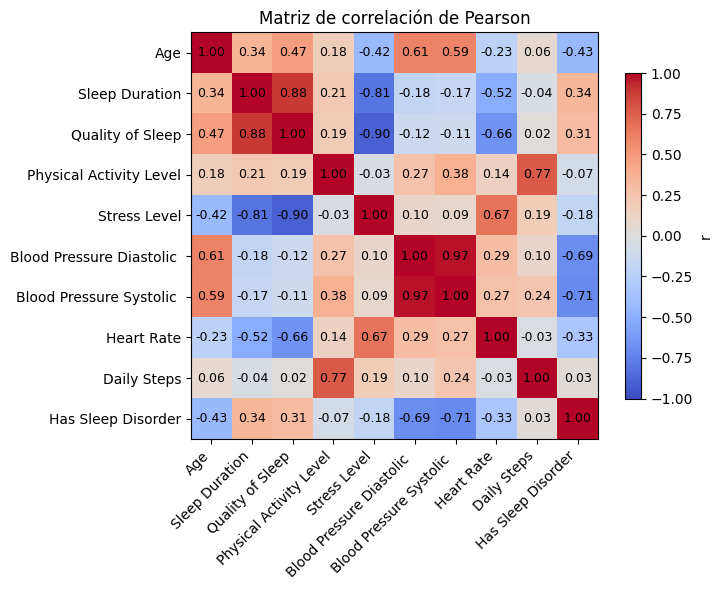

In [ ]:
# Matriz de correlación + mapa de calor
variables = ['Age','Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
             'Stress Level','Blood Pressure Diastolic ','Blood Pressure Systolic ',
             'Heart Rate','Daily Steps', 'Has Sleep Disorder']
corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(variables))); ax.set_xticklabels(variables, rotation=45, ha='right')
ax.set_yticks(range(len(variables))); ax.set_yticklabels(variables)
for i in range(len(variables)):
    for j in range(len(variables)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=9)
ax.set_title('Matriz de correlación de Pearson')
fig.colorbar(im, ax=ax, shrink=0.8, label='r')
plt.tight_layout()
plt.show()

**Paso 5**

Regresión lineal (modelo de aprendizaje supervisado)

La regresión lineal predice una variable numérica continua (la variable dependiente Y) a partir de una o más variables independientes X, asumiendo una relación lineal:

fw,b(x)=w1x1+w2x2+⋯+b

Objetivo: predecir la puntuación de la calidad del sueño (Sleep Duration) de una persona a partir de la duración del sueño en horas (Sleep_Duration_Hours), la frecuencia cardiaca (Heart Rate) y el nivel de estrés (Stress_Level).

Como en todo modelo supervisado, dividimos los datos en entrenamiento (para que el modelo aprenda) y prueba (para evaluarlo con datos que no ha visto).

Primero dividimos el data set entre data de entrenamiento y data de validación

In [73]:
features_lin = ['Sleep Duration', 'Heart Rate','Stress Level']
X = df[features_lin]
y = df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

Implementamos un modelo exploratorio para validar la importacia de las variables usadas usand o Ramdom Forest y SHAP

/tmp/ipykernel_1633/1010881187.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,X_test,plot_type="bar")


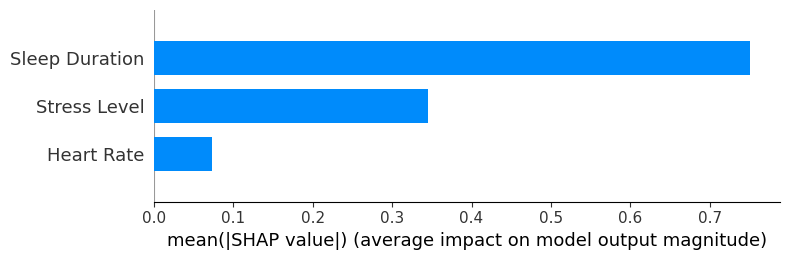

/tmp/ipykernel_1633/1010881187.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


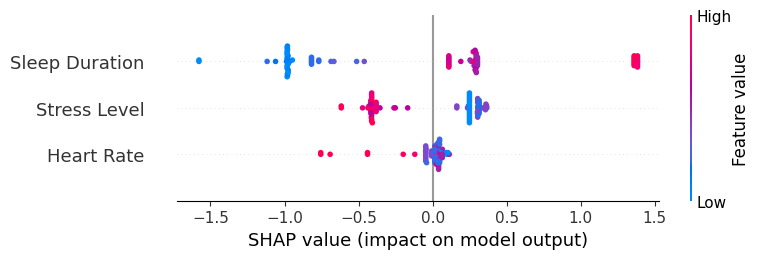

Ranking de variables según SHAP:


,Variable,Importancia_SHAP
0,Sleep Duration,0.751198
2,Stress Level,0.345518
1,Heart Rate,0.072697


In [74]:
# Modelo exploratorio
modelo_rf_shap = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1
)

modelo_rf_shap.fit(X_train, y_train)

masker = shap.maskers.Independent(
    X_train,
    max_samples=280
)

explainer = shap.Explainer(modelo_rf_shap, masker)

shap_values = explainer(X_test)

# IMPORTANCIA
shap.summary_plot(shap_values,X_test,plot_type="bar")
shap.summary_plot(shap_values, X_test)

# TABLA DE IMPORTANCIA
shap_importance = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia_SHAP': np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'Importancia_SHAP',
    ascending=False
)

print("Ranking de variables según SHAP:")
display(shap_importance)

Finalmente entrenamos el modelo para obtener sus respectivos coeficientes e intercepto

In [75]:
modelo_lin = LinearRegression()
modelo_lin.fit(X_train, y_train)

print("Coeficientes (w):")
for f, w in zip(features_lin, modelo_lin.coef_):
    print(f"   {f:<14}: {w:.4f}")
print(f"Intercepto (b): {modelo_lin.intercept_:.4f}")

Coeficientes (w):
   Sleep Duration: 0.7203
   Heart Rate    : -0.0218
   Stress Level  : -0.3067
Intercepto (b): 5.3629


### Evaluación del modelo de regresión

Métricas que vimos en clase (Evaluación de Modelos de Regresión):

- **R²**: qué proporción de la variabilidad explica el modelo (1 = perfecto).
- **MSE** (Error Cuadrático Medio) y **RMSE** (su raíz): penalizan errores grandes.
- **MAE** (Error Absoluto Medio): error promedio en las mismas unidades (goles).


R²   : 0.889
MSE  : 0.172
RMSE : 0.415  (Calidad del sueño)
MAE  : 0.334  (Calidad del sueño)


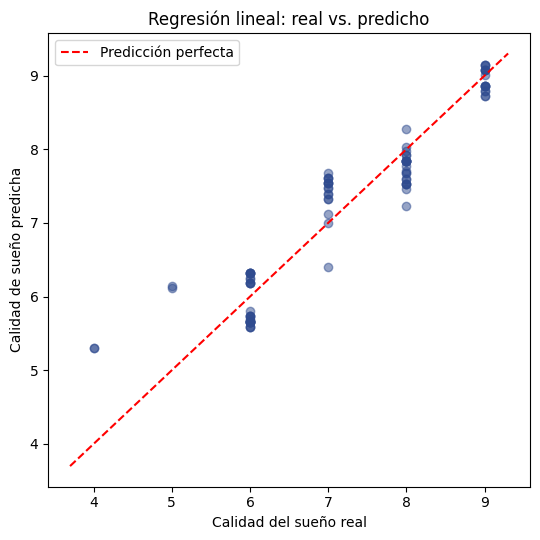

In [ ]:
y_pred = modelo_lin.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}  (Calidad del sueño)")
print(f"MAE  : {mae:.3f}  (Calidad del sueño)")

# Gráfico: valores reales vs. predichos
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred, alpha=0.5, color='#2f4b8f')
lims = [y_test.min()-0.3, y_test.max()+0.3]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Calidad del sueño real'); plt.ylabel('Calidad de sueño predicha')
plt.title('Regresión lineal: real vs. predicho')
plt.legend(); plt.tight_layout(); plt.show()

**Paso 7** ·

Regresión logística (clasificación binaria)
La regresión logística modela la probabilidad de que ocurra una categoría binaria (0 o 1) usando la función sigmoide:

p=11+e−(β0+β1X)

Si p > 0.5 (umbral de decisión), el modelo predice la clase 1; si no, la clase 0.

Objetivo: predecir si una persona tiene desorden del sueño a partir de sus características. Estandarizamos las variables porque la regresión logística es sensible a las escalas.

In [ ]:
features_log = ['Blood Pressure Diastolic ','Blood Pressure Systolic ','Sleep Duration', 'Quality of Sleep', 'Age']
Xl = df[features_log]
yl = df['Has Sleep Disorder']

# stratify mantiene la misma proporción de clases en train y test
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    Xl, yl, test_size=0.25, random_state=42, stratify=yl)

# Estandarización (media 0, desviación 1)
scaler = StandardScaler().fit(Xl_train)
Xl_train_s = scaler.transform(Xl_train)
Xl_test_s  = scaler.transform(Xl_test)

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(Xl_train_s, yl_train)

yl_pred = modelo_log.predict(Xl_test_s)
print("Modelo de regresión logística entrenado ✅")

Modelo de regresión logística entrenado ✅


### Evaluación del modelo de clasificación

Usamos la **matriz de confusión** y las métricas **precisión (precision)**,
**exhaustividad (recall)** y **F1-Score** que vimos en clase.

Exactitud (accuracy): 0.926
Precisión (precision): 0.962
Recall    (sensibilidad): 0.909
F1-Score  : 0.935

Reporte de clasificación:
                            precision    recall  f1-score   support

Sin problemas de sueño (0)       0.88      0.95      0.91        39
Con problemas de sueño (1)       0.96      0.91      0.93        55

                  accuracy                           0.93        94
                 macro avg       0.92      0.93      0.92        94
              weighted avg       0.93      0.93      0.93        94



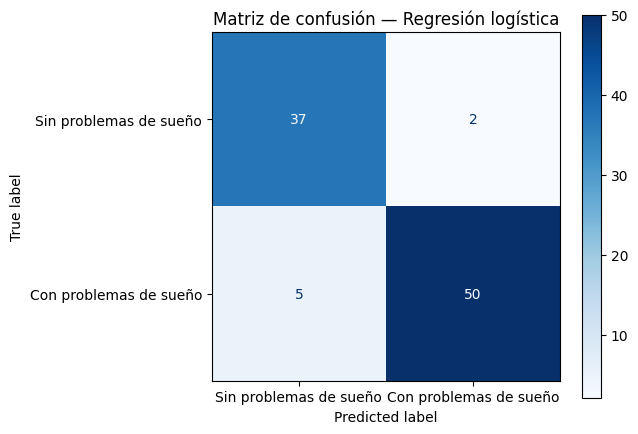

In [ ]:
acc  = accuracy_score(yl_test, yl_pred)
prec = precision_score(yl_test, yl_pred)
rec  = recall_score(yl_test, yl_pred)
f1   = f1_score(yl_test, yl_pred)

print(f"Exactitud (accuracy): {acc:.3f}")
print(f"Precisión (precision): {prec:.3f}")
print(f"Recall    (sensibilidad): {rec:.3f}")
print(f"F1-Score  : {f1:.3f}")
print("\nReporte de clasificación:")
print(classification_report(yl_test, yl_pred,
      target_names=['Sin problemas de sueño (0)', 'Con problemas de sueño (1)']))

# Matriz de confusión
cm = confusion_matrix(yl_test, yl_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=['Sin problemas de sueño', 'Con problemas de sueño'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — Regresión logística')
plt.tight_layout(); plt.show()

### Significancia de los coeficientes (valor-p) con `statsmodels`

In [ ]:
Xl_sm = sm.add_constant(df[features_log])
logit = sm.Logit(df['Has Sleep Disorder'], Xl_sm).fit(disp=0)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:     Has Sleep Disorder   No. Observations:                  374
Model:                          Logit   Df Residuals:                      368
Method:                           MLE   Df Model:                            5
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                  0.6073
Time:                        14:24:10   Log-Likelihood:                -99.634
converged:                       True   LL-Null:                       -253.73
Covariance Type:            nonrobust   LLR p-value:                 1.728e-64
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        27.4760      7.207      3.812      0.000      13.350      41.602
Blood Pressure Diastolic     -0.0903      0.151     -0.599      0.549      -0.386     